<div style="
    border: 2px solid #2c3e50;
    border-radius: 12px;
    padding: 20px;
    background-color: #f8f9fa;
    margin: 10px 0 20px 0;
    box-shadow: 0 2px 8px rgba(0,0,0,0.08);
">

  <h1 style="margin: 0; color: #1f3b73; font-size: 28px;">
    Notebook 03 — Assumptions of Linear Programming
  </h1>

  <h2 style="margin: 10px 0 18px 0; color: #34495e; font-size: 20px; font-weight: normal;">
    Python for Operations Research
  </h2>

  <hr style="border: none; border-top: 1px solid #cfd8dc; margin: 15px 0;">

  <p style="margin: 6px 0; font-size: 16px;">
    <b>Amirkabir University of Technology (Tehran Polytechnic)</b>
  </p>

  <p style="margin: 6px 0; font-size: 15px;">
    <b>Prof:</b> Dr. A. Golroo
  </p>

  <p style="margin: 6px 0; font-size: 15px;">
    <b>Mentor:</b> Parsa Sadri
  </p>

</div>


<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    0. Problem Definition
  </h2>
</div>


Linear Programming models are powerful, but they rely on several key assumptions.

These assumptions make the problem mathematically tractable and allow
algorithms like the **Simplex method** to work efficiently.

The four main assumptions are:

1. **Proportionality**
2. **Additivity**
3. **Divisibility**
4. **Certainty**

In this notebook we will:

- explain each assumption
- show when it is realistic
- show when it fails
- implement small examples in Python


<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    1. Proportionality
  </h2>
</div>


The proportionality assumption states that:

> The contribution of each decision variable to the objective
> and constraints is proportional to its value.

## Example

If producing 1 unit of product A requires:

- 2 hours of machine time

Then producing 5 units requires:

- 10 hours of machine time

The relationship is **linear**.


---
## Example

A bakery produces cakes.

Each cake requires:

- 0.5 kg flour
- 20 minutes of labor

If the bakery produces:

10 cakes → flour = 5 kg  
20 cakes → flour = 10 kg

The relationship is proportional.

---

However, proportionality does not always hold.

Example:

Factories often receive **bulk discounts** on raw materials.

Example pricing:

First 100 kg → $5 per kg$ 

Above 100 kg → $4 per kg$

The cost is no longer proportional to quantity.

This introduces **nonlinearity**.


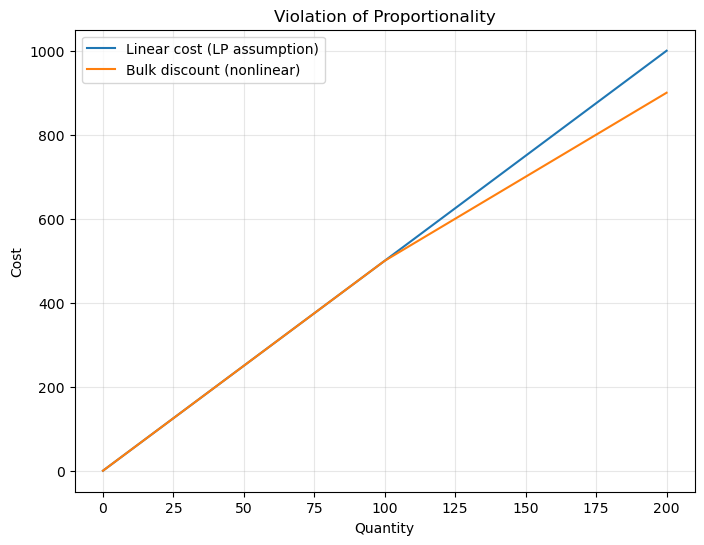

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0,200,200)

# proportional cost
linear_cost = 5*x

# bulk discount cost
nonlinear_cost = np.where(x<=100, 5*x, 500 + 4*(x-100))

plt.figure(figsize=(8,6))
plt.plot(x, linear_cost, label="Linear cost (LP assumption)")
plt.plot(x, nonlinear_cost, label="Bulk discount (nonlinear)")
plt.legend()
plt.xlabel("Quantity")
plt.ylabel("Cost")
plt.title("Violation of Proportionality")
plt.grid(alpha=0.3)
plt.show()


<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    2. Additivity
  </h2>
</div>


The additivity assumption states:

> The total effect of all activities is the sum of their individual effects.

There are **no interaction effects** between variables.


### Example

A factory produces two products:

A requires 2 hours machine time  
B requires 3 hours machine time

If we produce:

10 units of A  
5 units of B

Total machine time:

= 2×10 + 3×5
= 35 hours

The contributions are simply added together.


In real systems, interactions often exist.

### Example

Running products A and B together might reduce setup time.

### Example

If A and B are produced together,
a shared setup saves 2 hours.

Now the total machine time becomes:

2A + 3B − 2

This interaction term violates the **additivity assumption**.


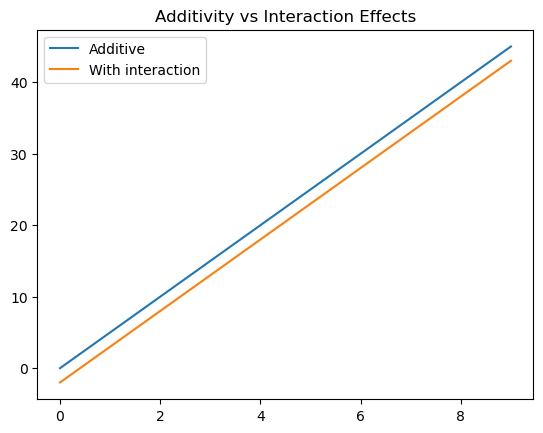

In [2]:
A = np.arange(0,20)
B = np.arange(0,20)

# additive model
machine_add = 2*A + 3*B

# interaction model
machine_interaction = 2*A + 3*B - 2

plt.plot(machine_add[:10], label="Additive")
plt.plot(machine_interaction[:10], label="With interaction")

plt.legend()
plt.title("Additivity vs Interaction Effects")
plt.show()


Divisibility assumes that decision variables can take **fractional values**.

Example solution:

x = 4.7 units

This is acceptable in LP.

In many real problems this is unrealistic.


<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    3. Divisibility
  </h2>
</div>


Divisibility assumes that decision variables can take **fractional values**.

Example solution:

x = 4.7 units

This is acceptable in LP.

In many real problems this is unrealistic.


### Example where divisibility is reasonable

Electricity production

Power plants can produce:

134.5 MW  
278.2 MW

Fractional values are perfectly valid.


### Example where divisibility fails

Airplanes

We cannot buy:

3.7 airplanes

The decision must be:

3 or 4 airplanes

This leads to **Integer Programming**.


In [3]:
import pulp

model = pulp.LpProblem("PlanePurchase", pulp.LpMaximize)

planes = pulp.LpVariable("planes", lowBound=0)

model += 100*planes
model += planes <= 3.7

model.solve()

print("LP solution:", planes.varValue)


LP solution: 3.7


LP may suggest:

3.7 airplanes

which is **impossible in reality**.

To fix this we use:

Integer Programming.


<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    4. Certainty
  </h2>
</div>


The certainty assumption means that:

> All model parameters are known with certainty.

This includes:

- costs
- profits
- resource capacities
- demand


### Example

Profit per unit = $5

LP assumes this value is **exact and known**.

In reality, many parameters are uncertain.

### Example

Profit per unit might be between:

4 and 6 depending on market demand.

Labor availability might vary.

These problems lead to:

- stochastic optimization
- robust optimization


In [4]:
import numpy as np

profits = np.random.normal(5,1,1000)

print("Average profit:", profits.mean())
print("Std deviation:", profits.std())

Average profit: 5.0275655486968205
Std deviation: 1.0382802474354984


<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    5. Summary
  </h2>
</div>


Linear Programming relies on four key assumptions:

1. Proportionality
2. Additivity
3. Divisibility
4. Certainty

When these assumptions are violated, we must use more advanced models:

- Integer Programming
- Nonlinear Programming
- Stochastic Optimization
- Robust Optimization

Understanding these assumptions is essential before applying LP
to real-world problems.


<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    6. Case Study: Airline Flight Planning
  </h2>
</div>


An airline company operates flights from **Tehran** to several destinations.

Routes:

- Tehran – Dubai
- Tehran – Istanbul
- Tehran – Doha

The airline operates two types of aircraft:

- Airbus A320
- Boeing 737

The company must decide:

> How many flights to operate on each route with each aircraft type.

The objective is to **maximize total profit**.

---

## Routes

| Route | Daily Demand | Ticket Price ($) |
|------|-------------|----------------|
Tehran–Dubai | 500 | 200  
Tehran–Istanbul | 400 | 250  
Tehran–Doha | 300 | 220  

---

## Aircraft Types

| Aircraft | Capacity | Cost per Flight ($) | Available |
|---------|---------|--------------------|-----------|
A320 | 180 | 18000 | 4  
B737 | 160 | 15000 | 5  

---

## Decision Variable

Let

x(r,a) = number of flights on route r using aircraft a

---

## Objective

Maximize total profit:

profit = revenue − operating cost


<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    6.1. Proportionality
  </h2>
</div>


The proportionality assumption states that:

> The contribution of each decision variable is proportional to its value.

Example:

If one flight generates \$30,000 revenue, then:

2 flights → \$60,000 

3 flights → \$90,000

Mathematically:

Revenue = c × x

This means the relationship is **linear**.


## Violation in the Real World

In reality, airline ticket prices often **decrease when the number of flights increases**.

More flights → more seats → price competition.

Therefore revenue per flight may decrease as supply increases.

This creates a **nonlinear relationship**.


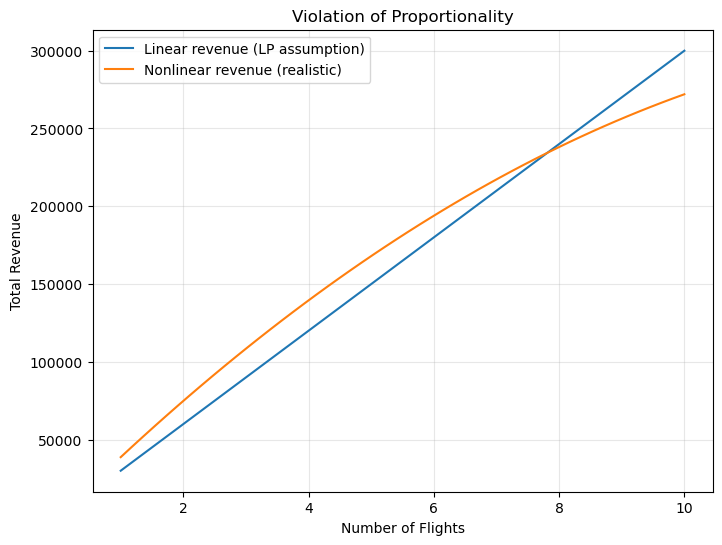

In [5]:
import numpy as np
import matplotlib.pyplot as plt

flights = np.linspace(1,10,50)

# linear revenue assumption
linear_revenue = 30000 * flights

# nonlinear revenue (price drops when flights increase)
price = 250 - 8*flights
nonlinear_revenue = price * 160 * flights

plt.figure(figsize=(8,6))

plt.plot(flights, linear_revenue, label="Linear revenue (LP assumption)")
plt.plot(flights, nonlinear_revenue, label="Nonlinear revenue (realistic)")

plt.xlabel("Number of Flights")
plt.ylabel("Total Revenue")
plt.title("Violation of Proportionality")

plt.legend()
plt.grid(alpha=0.3)

plt.show()


<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    6.2. Additivity
  </h2>
</div>


The additivity assumption states:

> The total effect is the sum of individual effects.

Example:

Total machine time:

2A + 3B

Each product contributes independently to the constraint.

## Violation in Airline Systems

Airline networks often have **connecting passengers**.

Example:

Passengers may travel:

Tehran → Dubai → Istanbul

Therefore increasing flights to Dubai may increase demand for Istanbul flights.

This creates an **interaction effect** between variables.

Mathematically:

Profit = c₁x₁ + c₂x₂ + γ x₁x₂

The interaction term makes the model **nonlinear**.


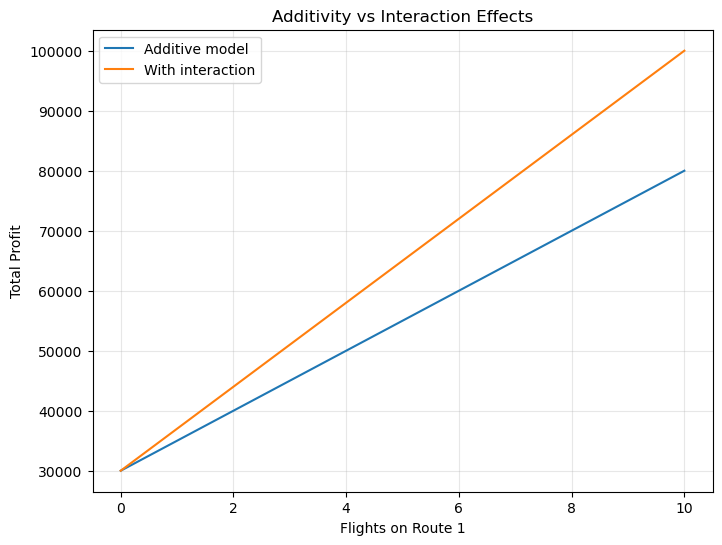

In [6]:
x1 = np.linspace(0,10,100)
x2 = 5

# additive model
additive_profit = 5000*x1 + 6000*x2

# interaction model
interaction_profit = 5000*x1 + 6000*x2 + 400*x1*x2

plt.figure(figsize=(8,6))

plt.plot(x1, additive_profit, label="Additive model")
plt.plot(x1, interaction_profit, label="With interaction")

plt.xlabel("Flights on Route 1")
plt.ylabel("Total Profit")

plt.title("Additivity vs Interaction Effects")

plt.legend()
plt.grid(alpha=0.3)

plt.show()


<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    6.3. Divisibility
  </h2>
</div>


Linear Programming assumes that decision variables can take **fractional values**.

Example solution:

x = 3.7

In many real problems this is unrealistic.


## Violation in Airline Planning

Flights must be integer numbers.

We cannot schedule:

3.7 flights per day

The decision must be:

3 flights or 4 flights

This type of problem requires **Integer Programming**.


In [7]:
import pulp

model = pulp.LpProblem("FlightPlanning", pulp.LpMaximize)

flights = pulp.LpVariable("Flights", lowBound=0)

model += 10000 * flights

model += flights <= 3.7

model.solve()

print("LP Solution:", flights.varValue)


LP Solution: 3.7


The LP solver may return:

Flights = 3.7

But this is not realistic.

To enforce integer values we must use:

Integer Programming.


<div style="
    border-left: 6px solid #1f3b73;
    background-color: #eef3f8;
    padding: 12px 16px;
    margin: 18px 0 12px 0;
    border-radius: 8px;
">
  <h2 style="margin: 0; color: #1f3b73; font-size: 22px;">
    6.4. Certainty
  </h2>
</div>


Linear Programming assumes that **all parameters are known exactly**.

Examples:

- ticket price
- demand
- fuel cost
- labor availability

In real life these parameters are uncertain.


## Example: Uncertain Demand

Passenger demand varies depending on:

- season
- holidays
- economic conditions

Instead of a fixed number, demand is often modeled as a **random variable**.


In [8]:
import numpy as np

demand_samples = np.random.normal(500,50,1000)

print("Average demand:", demand_samples.mean())
print("Standard deviation:", demand_samples.std())

Average demand: 499.6798681057793
Standard deviation: 49.7534815077295
